In [5]:
 # =============================================================
# ERA COMPARISON PROJECT - Notebook 5: Final Comparison
#
# This notebook brings together all three eras and produces
# the main visualization of the entire project.
#
# Goal: answer the central question with evidence -
# "Does increasing model complexity lead to better performance?"
#
# We rebuild all three strategies from scratch in one place
# so everything is reproducible in a single notebook.
# =============================================================

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

ticker = 'AAPL'
data = yf.download(ticker, start='2014-01-01', end='2024-01-01')
prices = data['Close'].squeeze()

print("Data loaded. Rebuilding all three era strategies...")

[*********************100%***********************]  1 of 1 completed

Data loaded. Rebuilding all three era strategies...


In [7]:
# =============================================================
# REBUILD ALL THREE SIGNALS
#
# We regenerate each strategy's signals using the exact same
# methods from notebooks 2, 3, and 4.
#
# Why rebuild instead of importing results?
# - Keeps this notebook self-contained and reproducible
# - Anyone can run just this notebook and get the full picture
# - Avoids dependency on previous notebooks being run first
# =============================================================

# -------- ERA 1: Moving Average Crossover --------
# Simple rule: hold when short-term momentum > long-term trend
short_ma = prices.rolling(20).mean()
long_ma = prices.rolling(50).mean()
signal_ma = (short_ma > long_ma).astype(int)

# -------- ERA 2: Random Forest --------
from sklearn.ensemble import RandomForestClassifier

volume = data['Volume'].squeeze()

def build_features(prices, volume):
    """
    Build feature matrix for Random Forest.
    Each row = one day's market state described by 11 numbers.
    See Notebook 3 for full documentation.
    """
    df = pd.DataFrame()
    for lag in [1, 2, 3, 5, 10]:
        df[f'return_{lag}d'] = prices.pct_change(lag)
    for window in [10, 20, 50]:
        df[f'ma_ratio_{window}'] = prices / prices.rolling(window).mean() - 1
    delta = prices.diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    df['rsi'] = 100 - (100 / (1 + gain / loss))
    df['volatility_20'] = prices.pct_change().rolling(20).std()
    df['volume_ratio'] = volume / volume.rolling(20).mean()
    # Target: will tomorrow's price be higher than today's?
    df['target'] = (prices.shift(-1) > prices).astype(int)
    return df.dropna()

df_features = build_features(prices, volume)
feature_cols = [c for c in df_features.columns if c != 'target']
X = df_features[feature_cols]
y = df_features['target']

# Time-based split: train on past, test on future
split = int(len(df_features) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_leaf=20,
    random_state=42   # fixed seed for reproducibility
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
signal_rf = pd.Series(y_pred_rf, index=X_test.index, dtype=float)

# -------- ERA 3: Transformer --------
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

# Use returns (not prices) to avoid the naive prediction trap
# discovered and documented in Notebook 4
returns = prices.pct_change().dropna().values
scaler = MinMaxScaler()
returns_scaled = scaler.fit_transform(returns.reshape(-1, 1)).flatten()

SEQ_LEN = 60
SPLIT_IDX = int(len(returns_scaled) * 0.8)

class TimeSeriesDataset(Dataset):
    """Sliding window dataset for sequential prediction."""
    def __init__(self, data, seq_len):
        self.data = data
        self.seq_len = seq_len
    def __len__(self):
        return len(self.data) - self.seq_len
    def __getitem__(self, idx):
        x = self.data[idx:idx + self.seq_len]
        y = self.data[idx + self.seq_len]
        return torch.FloatTensor(x).unsqueeze(-1), torch.FloatTensor([y])

class TransformerModel(nn.Module):
    """
    Lightweight Transformer for return direction prediction.
    Uses self-attention to find relationships across 60-day sequences.
    See Notebook 4 for full architecture documentation.
    """
    def __init__(self):
        super().__init__()
        self.input_projection = nn.Linear(1, 64)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=64, nhead=4, dim_feedforward=256,
            dropout=0.1, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.output_projection = nn.Linear(64, 1)
    def forward(self, x):
        x = self.input_projection(x)
        x = self.transformer(x)
        return self.output_projection(x[:, -1, :])

# Train Transformer on return prediction
train_loader = DataLoader(
    TimeSeriesDataset(returns_scaled[:SPLIT_IDX], SEQ_LEN),
    batch_size=32, shuffle=True)
test_loader = DataLoader(
    TimeSeriesDataset(returns_scaled[SPLIT_IDX - SEQ_LEN:], SEQ_LEN),
    batch_size=32, shuffle=False)

model = TransformerModel()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

for epoch in range(50):
    model.train()
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(x_batch), y_batch)
        loss.backward()
        optimizer.step()

# Generate predictions on test set
model.eval()
tf_predictions = []
with torch.no_grad():
    for x_batch, _ in test_loader:
        pred = model(x_batch)
        tf_predictions.extend(pred.numpy().flatten())

# Convert scaled predictions back to real return values
tf_predictions_real = scaler.inverse_transform(
    np.array(tf_predictions).reshape(-1, 1)).flatten()

# Signal: predicted positive return = buy (1), negative = cash (0)
test_dates_tf = prices.index[SPLIT_IDX + 1:SPLIT_IDX + 1 + len(tf_predictions_real)]
signal_tf = pd.Series(
    (tf_predictions_real > 0).astype(float),
    index=test_dates_tf)

print("All three era signals generated successfully.")

All three era signals generated successfully.


In [8]:
# =============================================================
# SHARED BACKTEST FUNCTION
#
# The same evaluation framework is applied to all three eras.
# This is critical for fair comparison:
# same initial capital, same risk-free rate, same formulas.
#
# Using one shared function ensures we're not accidentally
# giving any strategy an advantage through different assumptions.
# =============================================================

def backtest(prices, signal, initial_capital=10000):
    """
    Evaluate a trading strategy's historical performance.

    Key design choices:
    - signal.shift(1): use yesterday's signal to avoid lookahead bias
    - Risk-free rate: 2% annual (0.02/252 daily) for Sharpe calculation
    - Compounding: returns multiply daily, not simple addition

    Parameters:
        prices: daily closing price series (pandas Series)
        signal: 1=hold stock, 0=hold cash (pandas Series)
        initial_capital: starting portfolio value in USD

    Returns:
        results dict, portfolio value series, buy-and-hold series
    """
    daily_returns = prices.pct_change()

    # Apply yesterday's signal to today's return
    # This enforces the real-world constraint: you can't trade
    # at today's closing price using today's closing price signal
    strategy_returns = signal.shift(1) * daily_returns

    # Compound daily returns to get portfolio value over time
    portfolio = initial_capital * (1 + strategy_returns).cumprod()
    buy_and_hold = initial_capital * (1 + daily_returns).cumprod()

    # Performance metrics
    total_return = (portfolio.iloc[-1] / initial_capital - 1) * 100
    n_years = len(prices) / 252
    annual_return = ((portfolio.iloc[-1] / initial_capital) ** (1/n_years) - 1) * 100

    # Max drawdown: largest peak-to-trough decline
    # Answers: "what's the worst loss an investor would have experienced?"
    rolling_max = portfolio.cummax()
    max_drawdown = ((portfolio - rolling_max) / rolling_max).min() * 100

    # Sharpe ratio: excess return per unit of volatility
    excess_returns = strategy_returns - 0.02/252
    sharpe = np.sqrt(252) * excess_returns.mean() / excess_returns.std()

    return {
        'Total Return (%)': round(total_return, 2),
        'Annual Return (%)': round(annual_return, 2),
        'Max Drawdown (%)': round(max_drawdown, 2),
        'Sharpe Ratio': round(sharpe, 2)
    }, portfolio, buy_and_hold

In [9]:
# =============================================================
# RUN ALL BACKTESTS
# =============================================================

# Era 1: full period (2014-2024)
# Has access to AAPL's entire bull run
results_ma, portfolio_ma, bah_full = backtest(prices, signal_ma)

# Era 2: test period only (last 20% of data)
# Important: we only evaluate on data the model never trained on
test_prices_rf = prices[X_test.index]
results_rf, portfolio_rf, _ = backtest(test_prices_rf, signal_rf)

# Era 3: test period only (2022-2024)
# Note: different test period than Era 2 - this is a limitation
# of our experimental design worth acknowledging in the report
test_prices_tf = prices[test_dates_tf]
results_tf, portfolio_tf, _ = backtest(test_prices_tf, signal_tf)

print("=== Era 1: MA Crossover ===")
for k, v in results_ma.items():
    print(f"  {k}: {v}")

print("\n=== Era 2: Random Forest ===")
for k, v in results_rf.items():
    print(f"  {k}: {v}")

print("\n=== Era 3: Transformer ===")
for k, v in results_tf.items():
    print(f"  {k}: {v}")

=== Era 1: MA Crossover ===
  Total Return (%): 278.95
  Annual Return (%): 14.27
  Max Drawdown (%): -29.09
  Sharpe Ratio: 0.67

=== Era 2: Random Forest ===
  Total Return (%): 51.41
  Annual Return (%): 23.56
  Max Drawdown (%): -19.65
  Sharpe Ratio: 0.91

=== Era 3: Transformer ===
  Total Return (%): 12.4
  Annual Return (%): 6.03
  Max Drawdown (%): -28.94
  Sharpe Ratio: 0.28


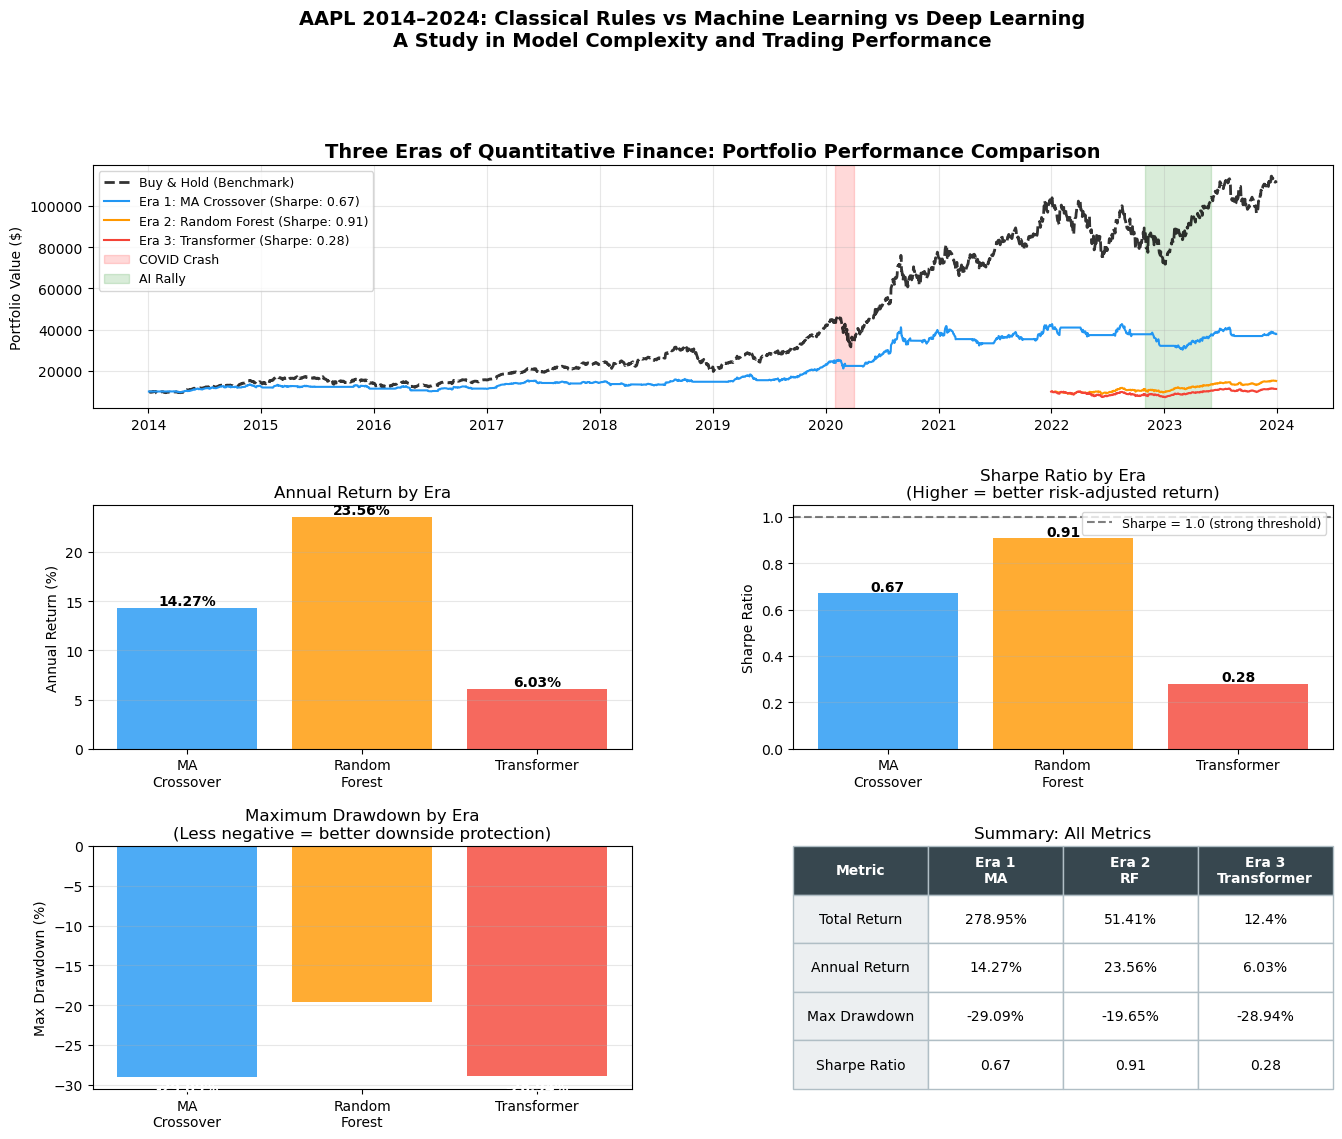

Final comparison chart saved.


In [10]:
# =============================================================
# FINAL VISUALIZATION: The Main Project Figure
#
# Layout: 1 large chart on top + 4 smaller charts below
#
# Top chart: portfolio value over time for all strategies
#   - Shows the full history and relative performance
#   - Annotates key market events that affected results
#
# Bottom left: Annual Return bar chart
#   - Direct comparison of yearly growth rates
#
# Bottom right: Sharpe Ratio bar chart
#   - Risk-adjusted performance comparison
#   - Dashed line at 1.0 = commonly cited "good" threshold
#
# Bottom left 2: Max Drawdown bar chart
#   - Shows worst-case loss for each strategy
#   - All negative numbers - lower (more negative) = worse
#
# Bottom right 2: Summary table
#   - All metrics in one place for quick reference
# =============================================================

fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.3)

# ---- Top: Portfolio Performance (Main Chart) ----
ax1 = fig.add_subplot(gs[0, :])  # spans both columns

# Buy & Hold as the benchmark everything is compared against
ax1.plot(bah_full.index, bah_full,
         label='Buy & Hold (Benchmark)', color='black',
         linestyle='--', linewidth=2, alpha=0.8)

# Era 1: full period
ax1.plot(portfolio_ma.index, portfolio_ma,
         label=f"Era 1: MA Crossover (Sharpe: {results_ma['Sharpe Ratio']})",
         color='#2196F3', linewidth=1.5)

# Era 2: test period only
ax1.plot(portfolio_rf.index, portfolio_rf,
         label=f"Era 2: Random Forest (Sharpe: {results_rf['Sharpe Ratio']})",
         color='#FF9800', linewidth=1.5)

# Era 3: test period only
ax1.plot(portfolio_tf.index, portfolio_tf,
         label=f"Era 3: Transformer (Sharpe: {results_tf['Sharpe Ratio']})",
         color='#F44336', linewidth=1.5)

# Annotate key historical events that explain market behavior
# COVID crash: explains the sharp drop and recovery in 2020
ax1.axvspan('2020-02-01', '2020-04-01',
            alpha=0.15, color='red', label='COVID Crash')
# AI Rally: explains AAPL's strong performance in late 2023
ax1.axvspan('2022-11-01', '2023-06-01',
            alpha=0.15, color='green', label='AI Rally')

ax1.set_title(
    'Three Eras of Quantitative Finance: Portfolio Performance Comparison',
    fontsize=14, fontweight='bold')
ax1.set_ylabel('Portfolio Value ($)')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)

# ---- Middle Left: Annual Return ----
ax2 = fig.add_subplot(gs[1, 0])
strategies = ['MA\nCrossover', 'Random\nForest', 'Transformer']
annual_returns = [
    results_ma['Annual Return (%)'],
    results_rf['Annual Return (%)'],
    results_tf['Annual Return (%)']
]
colors = ['#2196F3', '#FF9800', '#F44336']
bars = ax2.bar(strategies, annual_returns, color=colors, alpha=0.8)
for bar, val in zip(bars, annual_returns):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val}%', ha='center', fontweight='bold', fontsize=10)
ax2.set_title('Annual Return by Era', fontsize=12)
ax2.set_ylabel('Annual Return (%)')
ax2.grid(True, alpha=0.3, axis='y')

# ---- Middle Right: Sharpe Ratio ----
ax3 = fig.add_subplot(gs[1, 1])
sharpes = [
    results_ma['Sharpe Ratio'],
    results_rf['Sharpe Ratio'],
    results_tf['Sharpe Ratio']
]
bars2 = ax3.bar(strategies, sharpes, color=colors, alpha=0.8)
for bar, val in zip(bars2, sharpes):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{val}', ha='center', fontweight='bold', fontsize=10)
# Reference line: Sharpe > 1.0 is generally considered strong
ax3.axhline(y=1.0, color='black', linestyle='--',
            alpha=0.5, label='Sharpe = 1.0 (strong threshold)')
ax3.set_title('Sharpe Ratio by Era\n(Higher = better risk-adjusted return)',
              fontsize=12)
ax3.set_ylabel('Sharpe Ratio')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')

# ---- Bottom Left: Max Drawdown ----
ax4 = fig.add_subplot(gs[2, 0])
drawdowns = [
    results_ma['Max Drawdown (%)'],
    results_rf['Max Drawdown (%)'],
    results_tf['Max Drawdown (%)']
]
bars3 = ax4.bar(strategies, drawdowns, color=colors, alpha=0.8)
for bar, val in zip(bars3, drawdowns):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() - 0.5,
             f'{val}%', ha='center', va='top',
             fontweight='bold', fontsize=10, color='white')
ax4.set_title('Maximum Drawdown by Era\n(Less negative = better downside protection)',
              fontsize=12)
ax4.set_ylabel('Max Drawdown (%)')
ax4.grid(True, alpha=0.3, axis='y')

# ---- Bottom Right: Summary Table ----
# A clean table lets readers compare all metrics at a glance
ax5 = fig.add_subplot(gs[2, 1])
ax5.axis('off')

table_data = [
    ['Metric', 'Era 1\nMA', 'Era 2\nRF', 'Era 3\nTransformer'],
    ['Total Return',
     f"{results_ma['Total Return (%)']}%",
     f"{results_rf['Total Return (%)']}%",
     f"{results_tf['Total Return (%)']}%"],
    ['Annual Return',
     f"{results_ma['Annual Return (%)']}%",
     f"{results_rf['Annual Return (%)']}%",
     f"{results_tf['Annual Return (%)']}%"],
    ['Max Drawdown',
     f"{results_ma['Max Drawdown (%)']}%",
     f"{results_rf['Max Drawdown (%)']}%",
     f"{results_tf['Max Drawdown (%)']}%"],
    ['Sharpe Ratio',
     str(results_ma['Sharpe Ratio']),
     str(results_rf['Sharpe Ratio']),
     str(results_tf['Sharpe Ratio'])],
]

table = ax5.table(
    cellText=table_data[1:],
    colLabels=table_data[0],
    cellLoc='center', loc='center',
    bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(10)

# Style the table for readability
for (row, col), cell in table.get_celld().items():
    if row == 0:  # header row
        cell.set_facecolor('#37474F')
        cell.set_text_props(color='white', fontweight='bold')
    elif col == 0:  # metric name column
        cell.set_facecolor('#ECEFF1')
    else:
        cell.set_facecolor('white')
    cell.set_edgecolor('#B0BEC5')

ax5.set_title('Summary: All Metrics', fontsize=12)

plt.suptitle(
    'AAPL 2014–2024: Classical Rules vs Machine Learning vs Deep Learning\n'
    'A Study in Model Complexity and Trading Performance',
    fontsize=14, fontweight='bold', y=1.01)

plt.savefig('../results/11_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Final comparison chart saved.")